# Phase 2: Models — Tabular, Text, and Gated Cross-Modal Attention Fusion

This notebook trains four models on the features produced by `04_phase2_text_encoding.ipynb`:

1. Tabular-only MLP — the 75 CRM / engineered features.
2. Text-only MLP — DistilBERT 768-dim `[CLS]` features.
3. Concat Fusion — both branches encoded separately and concatenated before the head.
4. GCMA Fusion — tabular and text fused through cross-attention over K learned views of the text `[CLS]`, with a learned gate mixing the two modalities per sample.

Input: `saas_features_pretrained.parquet` (8000 rows × 844 cols — 75 tabular + 768 text + 1 target).

## Setup — imports, seeds, device

Seed 42 throughout so the split matches notebook 04 exactly. Standard PyTorch + sklearn stack.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data loading and train/val/test split

Three column groups in the Parquet: the `outcome` label, 75 tabular features, and 768 `tok_*` columns from DistilBERT. We do a 70/15/15 stratified split with seed 42. Validation drives early stopping; the test set is held back for the final evaluation only.

In [2]:
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet("/content/saas_features_pretrained (2).parquet")
print(f"Loaded: {df.shape}")

TEXT_COLS = [f'tok_{i}' for i in range(768)]
TAB_COLS = [c for c in df.columns if c not in TEXT_COLS and c != 'outcome']
print(f"Tabular features: {len(TAB_COLS)} | text features: {len(TEXT_COLS)}")

# Cast bool columns (from get_dummies) to float
for c in TAB_COLS:
    if df[c].dtype == bool:
        df[c] = df[c].astype(float)

X_tab = df[TAB_COLS].values.astype(np.float32)
X_text = df[TEXT_COLS].values.astype(np.float32)
y = df['outcome'].values.astype(np.float32)

# 70% train, 15% val, 15% test — stratified
X_tab_train, X_tab_temp, X_text_train, X_text_temp, y_train, y_temp = train_test_split(
    X_tab, X_text, y, test_size=0.30, stratify=y, random_state=SEED
)
X_tab_val, X_tab_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_tab_temp, X_text_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# --- Post-split rescaling (fit on train only, no leakage) ----------------
# Notebook 04 left raw text_length / word_count / conversation_length unscaled,
# and DistilBERT [CLS] is uncentered. Both cause gradient instability in the
# single-modality and concat models. Apply StandardScaler to both matrices.
print(f"\nBefore rescale  X_tab  train: mean={X_tab_train.mean():+.3f}  std={X_tab_train.std():.3f}  max|={np.abs(X_tab_train).max():.1f}")
print(f"Before rescale  X_text train: mean={X_text_train.mean():+.3f}  std={X_text_train.std():.3f}")

tab_scaler = StandardScaler().fit(X_tab_train)
X_tab_train = tab_scaler.transform(X_tab_train).astype(np.float32)
X_tab_val   = tab_scaler.transform(X_tab_val).astype(np.float32)
X_tab_test  = tab_scaler.transform(X_tab_test).astype(np.float32)

text_scaler = StandardScaler().fit(X_text_train)
X_text_train = text_scaler.transform(X_text_train).astype(np.float32)
X_text_val   = text_scaler.transform(X_text_val).astype(np.float32)
X_text_test  = text_scaler.transform(X_text_test).astype(np.float32)

print(f"\nAfter rescale   X_tab  train: mean={X_tab_train.mean():+.3f}  std={X_tab_train.std():.3f}  max|={np.abs(X_tab_train).max():.1f}")
print(f"After rescale   X_text train: mean={X_text_train.mean():+.3f}  std={X_text_train.std():.3f}")

print(f"\nTrain: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Train Won/Lost: {int(y_train.sum())}/{len(y_train) - int(y_train.sum())}")

Loaded: (8000, 844)
Tabular features: 75 | text features: 768

Before rescale  X_tab  train: mean=+20.134  std=150.550  max|=2563.0
Before rescale  X_text train: mean=-0.009  std=0.439

After rescale   X_tab  train: mean=+0.000  std=1.000  max|=5.3
After rescale   X_text train: mean=-0.000  std=1.000

Train: 5600 | Val: 1200 | Test: 1200
Train Won/Lost: 2786/2814


## Shared training utilities

One `train_model` helper shared by all four models so the training protocol is the same across them:

- Loss: `BCEWithLogitsLoss` (combining sigmoid + BCE in one op is more numerically stable).
- Optimizer: `AdamW` with weight decay `1e-4`.
- LR scheduler: `ReduceLROnPlateau` on val F1 (factor 0.5, patience 3).
- Early stopping: patience 7 on val F1; best checkpoint restored at the end.
- Max 50 epochs.

`make_loaders` accepts a list of feature matrices, so the same helper works for both single-modality and dual-modality models.

In [3]:
def make_loaders(Xs_train, Xs_val, Xs_test, y_train, y_val, y_test, batch_size=64):
    """Build DataLoaders from lists of feature matrices."""
    def to_ds(Xs, y):
        tensors = [torch.tensor(x) for x in Xs] + [torch.tensor(y).float()]
        return TensorDataset(*tensors)
    return (
        DataLoader(to_ds(Xs_train, y_train), batch_size=batch_size, shuffle=True),
        DataLoader(to_ds(Xs_val, y_val), batch_size=batch_size),
        DataLoader(to_ds(Xs_test, y_test), batch_size=batch_size),
    )


def train_model(model, train_loader, val_loader, *, epochs=50, lr=1e-3,
                weight_decay=1e-4, patience=7, label="model"):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()

    best_val_f1, best_state, bad_epochs = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            *inputs, y_b = [t.to(device) for t in batch]
            opt.zero_grad()
            logits = model(*inputs).squeeze(-1)
            loss = loss_fn(logits, y_b)
            loss.backward()
            opt.step()

        model.eval()
        all_logits, all_y = [], []
        with torch.no_grad():
            for batch in val_loader:
                *inputs, y_b = [t.to(device) for t in batch]
                logits = model(*inputs).squeeze(-1)
                all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
        val_logits = torch.cat(all_logits); val_y = torch.cat(all_y)
        val_preds = (val_logits.sigmoid() >= 0.5).int().numpy()
        val_f1 = f1_score(val_y.numpy(), val_preds)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[{label}] ep {ep:3d} | val F1 = {val_f1:.4f} | best = {best_val_f1:.4f}")
        if bad_epochs >= patience:
            print(f"[{label}] early stop at ep {ep} (patience {patience})")
            break

    model.load_state_dict(best_state)
    return model, best_val_f1


@torch.no_grad()
def evaluate(model, loader, label="model"):
    model.eval()
    all_logits, all_y = [], []
    for batch in loader:
        *inputs, y_b = [t.to(device) for t in batch]
        logits = model(*inputs).squeeze(-1)
        all_logits.append(logits.cpu()); all_y.append(y_b.cpu())
    logits = torch.cat(all_logits); ys = torch.cat(all_y)
    preds = (logits.sigmoid() >= 0.5).int().numpy()
    f1 = f1_score(ys.numpy(), preds)
    acc = accuracy_score(ys.numpy(), preds)
    print(f"[{label}] Test F1 = {f1:.4f} | Acc = {acc:.4f}")
    return {'f1': f1, 'acc': acc, 'preds': preds, 'logits': logits.numpy(), 'y': ys.numpy()}

## Step 1 — Tabular-only MLP

The 75 tabular features alone already do very well — Phase 1 showed an F1 around 0.97 with this kind of model. Training one here gives us the tabular ceiling we'll compare the fusion models against.

Architecture: `75 → 128 → 64 → 1` with ReLU and Dropout(0.3) between layers.

In [4]:
class TabularMLP(nn.Module):
    def __init__(self, in_dim, h1=128, h2=64, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(h1, h2),     nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(h2, 1),
        )
    def forward(self, x_tab):
        return self.net(x_tab)

tl_train, tl_val, tl_test = make_loaders(
    [X_tab_train], [X_tab_val], [X_tab_test], y_train, y_val, y_test
)
tab_model = TabularMLP(in_dim=X_tab_train.shape[1])
tab_model, _ = train_model(tab_model, tl_train, tl_val, label="TabularMLP")
tab_result = evaluate(tab_model, tl_test, label="TabularMLP")

[TabularMLP] ep   1 | val F1 = 0.9542 | best = 0.9542
[TabularMLP] ep   5 | val F1 = 0.9767 | best = 0.9766
[TabularMLP] ep  10 | val F1 = 0.9742 | best = 0.9791
[TabularMLP] ep  15 | val F1 = 0.9767 | best = 0.9799
[TabularMLP] early stop at ep 19 (patience 7)
[TabularMLP] Test F1 = 0.9664 | Acc = 0.9667


## Step 2 — Text-only DistilBERT MLP

How much signal does the conversation alone carry? In Phase 1, text-only models plateaued around F1 = 0.55–0.62 because of the PCA-20 bottleneck. Here we feed the full 768-dim `[CLS]` to see what a fuller representation can reach.

Architecture: `768 → 256 → 128 → 1` with ReLU and Dropout(0.3).

In [5]:
class TextMLP(nn.Module):
    def __init__(self, in_dim=768, h1=256, h2=128, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(h1, h2),     nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(h2, 1),
        )
    def forward(self, x_text):
        return self.net(x_text)

txt_train, txt_val, txt_test = make_loaders(
    [X_text_train], [X_text_val], [X_text_test], y_train, y_val, y_test
)
text_model = TextMLP()
text_model, _ = train_model(text_model, txt_train, txt_val, label="TextMLP")
text_result = evaluate(text_model, txt_test, label="TextMLP")

[TextMLP] ep   1 | val F1 = 0.6595 | best = 0.6595
[TextMLP] ep   5 | val F1 = 0.6942 | best = 0.7122
[TextMLP] ep  10 | val F1 = 0.7131 | best = 0.7154
[TextMLP] ep  15 | val F1 = 0.6983 | best = 0.7280
[TextMLP] early stop at ep 18 (patience 7)
[TextMLP] Test F1 = 0.7048 | Acc = 0.6992


## Step 3 — Concat Fusion (late-fusion baseline)

Encode each modality through its own MLP, concatenate the two representations, and pass through a shared head. This is a simple late-fusion baseline and stands in for the kind of fusion Phase 1 did.

Architecture:
- Tabular branch: `75 → 128` (ReLU + Dropout)
- Text branch: `768 → 128` (ReLU + Dropout)
- Head: `[h_tab ; h_text] → 128 → 1`

In [6]:
class ConcatFusion(nn.Module):
    def __init__(self, d_tab, d_text=768, d_hidden=128, p_drop=0.3):
        super().__init__()
        self.tab_enc  = nn.Sequential(nn.Linear(d_tab,  d_hidden), nn.ReLU(), nn.Dropout(p_drop))
        self.text_enc = nn.Sequential(nn.Linear(d_text, d_hidden), nn.ReLU(), nn.Dropout(p_drop))
        self.head = nn.Sequential(
            nn.Linear(2 * d_hidden, d_hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_hidden, 1),
        )
    def forward(self, x_tab, x_text):
        h_tab  = self.tab_enc(x_tab)
        h_text = self.text_enc(x_text)
        return self.head(torch.cat([h_tab, h_text], dim=-1))

cf_train, cf_val, cf_test = make_loaders(
    [X_tab_train, X_text_train], [X_tab_val, X_text_val], [X_tab_test, X_text_test],
    y_train, y_val, y_test,
)
concat_model = ConcatFusion(d_tab=X_tab_train.shape[1])
concat_model, _ = train_model(concat_model, cf_train, cf_val, label="ConcatFusion")
concat_result = evaluate(concat_model, cf_test, label="ConcatFusion")

[ConcatFusion] ep   1 | val F1 = 0.9671 | best = 0.9671
[ConcatFusion] ep   5 | val F1 = 0.9727 | best = 0.9784
[ConcatFusion] ep  10 | val F1 = 0.9757 | best = 0.9784
[ConcatFusion] early stop at ep 11 (patience 7)
[ConcatFusion] Test F1 = 0.9749 | Acc = 0.9750


## Step 4 — Gated Cross-Modal Attention Fusion

The idea here is that tabular and text shouldn't just be concatenated. Instead, the tabular representation acts as a query that attends over several learned views of the text, and a learned gate then decides per-sample how much of the attended text vs. the tabular branch to keep.

Architecture:

1. Tabular encoder: `75 → 128 → 128` with ReLU and Dropout.
2. Text views (K = 8): a single `Linear(768, 8·d)` reshaped into 8 learned 128-dim projections of the `[CLS]` vector. These 8 projections act as the sequence we attend over. Attending over a single `[CLS]` vector would be trivial (softmax over one key always gives 1), so we construct K > 1 learned views explicitly.
3. Cross-attention: Q comes from the tabular encoder (128-dim), K and V from the 8 text views. Output is `(B, 128)`, and the attention weights `(B, 1, 8)` are cached for inspection.
4. Sigmoid gate: `g = σ(W_g [h_tab ; z_attn])`, a `(B, 128)` tensor with a per-dimension, per-sample value.
5. Fused vector: `z = g ⊙ z_attn + (1 − g) ⊙ proj(h_tab)`, then LayerNorm, then a `128 → 64 → 1` classifier.

The gate weights `W_g` are initialized small so `σ(W_g · …) ≈ 0.5` at the start of training — the model starts out trusting both branches roughly equally and learns a per-sample preference from there.

In [7]:
class GCMA(nn.Module):
    """Gated Cross-Modal Attention: tabular queries K learned views of text, then gate-mixes with h_tab."""
    def __init__(self, d_tab, d_text=768, d_attn=128, num_views=8):
        super().__init__()
        self.num_views = num_views
        self.d_attn = d_attn

        # K learned "views" of the text CLS: single linear that produces num_views * d_attn floats
        self.text_views = nn.Linear(d_text, num_views * d_attn)

        # Q/K/V projections for cross-attention
        self.W_q = nn.Linear(d_tab,  d_attn)
        self.W_k = nn.Linear(d_attn, d_attn)
        self.W_v = nn.Linear(d_attn, d_attn)
        # Softer attention temperature (2x standard) — keeps softmax non-degenerate
        # early in training and prevents the entropy-0 collapse we saw in the first run.
        self.scale = (d_attn ** 0.5) * 2.0

        # Gate over (h_tab || z_attn).
        # Explicitly start the gate near 0.5 (balanced trust) by using small-gain init
        # on the weights and zero bias. This prevents the gate from saturating early
        # before the attention pathway has had a chance to learn.
        self.W_g = nn.Linear(d_tab + d_attn, d_attn)
        nn.init.xavier_normal_(self.W_g.weight, gain=0.1)
        nn.init.zeros_(self.W_g.bias)

        # Project h_tab to d_attn for gate mixing
        self.tab_proj = nn.Linear(d_tab, d_attn)

        self.ln = nn.LayerNorm(d_attn)

        # Caches for inspection
        self.last_attn_weights = None
        self.last_gate = None

    def forward(self, h_tab, h_text_cls):
        B = h_tab.size(0)
        # K views of the text CLS: (B, K, d_attn)
        h_views = self.text_views(h_text_cls).view(B, self.num_views, self.d_attn)

        Q = self.W_q(h_tab).unsqueeze(1)      # (B, 1, d_attn)
        K = self.W_k(h_views)                 # (B, K, d_attn)
        V = self.W_v(h_views)                 # (B, K, d_attn)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale    # (B, 1, K)
        attn = F.softmax(scores, dim=-1)                              # (B, 1, K)
        z_attn = torch.matmul(attn, V).squeeze(1)                     # (B, d_attn)

        h_tab_proj = self.tab_proj(h_tab)                                     # (B, d_attn)
        g = torch.sigmoid(self.W_g(torch.cat([h_tab, z_attn], dim=-1)))       # (B, d_attn)
        z_fused = g * z_attn + (1.0 - g) * h_tab_proj                         # (B, d_attn)
        z_fused = self.ln(z_fused)

        self.last_attn_weights = attn.detach().squeeze(1)   # (B, K)
        self.last_gate = g.detach()                         # (B, d_attn)
        return z_fused


class GCMAFusion(nn.Module):
    def __init__(self, d_tab, d_text=768, d_hidden=128, num_views=8, p_drop=0.3):
        super().__init__()
        self.tab_enc = nn.Sequential(
            nn.Linear(d_tab, d_hidden),    nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_hidden, d_hidden), nn.ReLU(), nn.Dropout(p_drop),
        )
        self.gcma = GCMA(d_tab=d_hidden, d_text=d_text, d_attn=d_hidden, num_views=num_views)
        self.head = nn.Sequential(
            nn.Linear(d_hidden, 64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )

    def forward(self, x_tab, x_text):
        h_tab = self.tab_enc(x_tab)
        z_fused = self.gcma(h_tab, x_text)
        return self.head(z_fused)


gcma_train, gcma_val, gcma_test = make_loaders(
    [X_tab_train, X_text_train], [X_tab_val, X_text_val], [X_tab_test, X_text_test],
    y_train, y_val, y_test,
)
gcma_model = GCMAFusion(d_tab=X_tab_train.shape[1])
n_params = sum(p.numel() for p in gcma_model.parameters() if p.requires_grad)
print(f"GCMA trainable params: {n_params:,}")
gcma_model, _ = train_model(gcma_model, gcma_train, gcma_val, label="GCMAFusion")
gcma_result = evaluate(gcma_model, gcma_test, label="GCMAFusion")

GCMA trainable params: 921,217
[GCMAFusion] ep   1 | val F1 = 0.9642 | best = 0.9642
[GCMAFusion] ep   5 | val F1 = 0.9767 | best = 0.9800
[GCMAFusion] ep  10 | val F1 = 0.9750 | best = 0.9800
[GCMAFusion] early stop at ep 10 (patience 7)
[GCMAFusion] Test F1 = 0.9615 | Acc = 0.9617


## Step 5 — Results comparison

All four models trained on the same split with the same optimizer and early-stopping policy, so the F1 values below reflect the model architecture rather than the training setup.

In [8]:
results = {
    "TabularMLP":             {'f1': tab_result['f1'],    'acc': tab_result['acc']},
    "TextMLP (DistilBERT)":   {'f1': text_result['f1'],   'acc': text_result['acc']},
    "ConcatFusion":           {'f1': concat_result['f1'], 'acc': concat_result['acc']},
    "GCMAFusion":             {'f1': gcma_result['f1'],   'acc': gcma_result['acc']},
}
results_df = pd.DataFrame.from_dict(results, orient='index').sort_values('f1')
print(results_df.to_string())
results_df.to_csv("phase2_results.csv")
print("\nSaved phase2_results.csv")

                            f1       acc
TextMLP (DistilBERT)  0.704824  0.699167
GCMAFusion            0.961538  0.961667
TabularMLP            0.966443  0.966667
ConcatFusion          0.974874  0.975000

Saved phase2_results.csv


## Quick interpretability peek

Two quick views into what GCMA learned. The full treatment is in `06_phase2_validation.ipynb` (ablations, confusion matrices, per-sample examples), but these two plots already give a sense of whether the gate and attention are doing anything non-trivial:

1. Gate distribution — mean gate value per test sample. Values close to 1 mean the model is trusting the text branch for that sample; close to 0 means it is trusting the tabular branch. If Won and Lost samples have visibly different gate distributions, the gate is being used as a per-sample modality selector.

2. Attention weights — softmax over the 8 learned text views. Uniform weights suggest attention isn't doing much; concentrated weights mean specific views drive specific decisions.

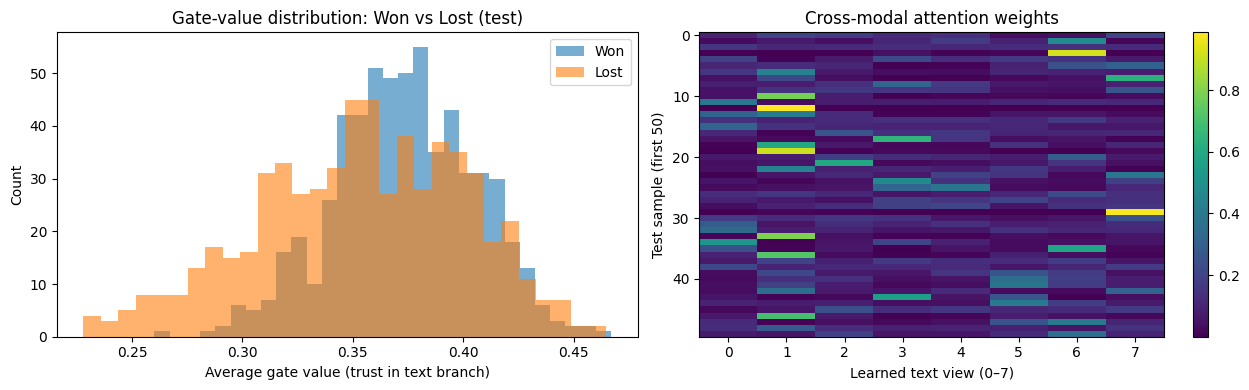

Mean gate (Won):  0.374
Mean gate (Lost): 0.354
Attention entropy (mean over samples): 1.639 nats (max = 2.079)


In [9]:
# Run GCMA once on the test set to cache attention + gate
gcma_model.eval()
with torch.no_grad():
    _ = gcma_model(torch.tensor(X_tab_test).to(device), torch.tensor(X_text_test).to(device))

attn = gcma_model.gcma.last_attn_weights.cpu().numpy()   # (N_test, K=8)
gate = gcma_model.gcma.last_gate.cpu().numpy()           # (N_test, d_attn=128)
gate_trust = gate.mean(axis=1)                           # scalar per sample

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gate_trust[y_test == 1], bins=30, alpha=0.6, label='Won')
axes[0].hist(gate_trust[y_test == 0], bins=30, alpha=0.6, label='Lost')
axes[0].set_xlabel('Average gate value (trust in text branch)')
axes[0].set_ylabel('Count')
axes[0].set_title('Gate-value distribution: Won vs Lost (test)')
axes[0].legend()

im = axes[1].imshow(attn[:50], aspect='auto', cmap='viridis')
axes[1].set_xlabel('Learned text view (0–7)')
axes[1].set_ylabel('Test sample (first 50)')
axes[1].set_title('Cross-modal attention weights')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Mean gate (Won):  {gate_trust[y_test == 1].mean():.3f}")
print(f"Mean gate (Lost): {gate_trust[y_test == 0].mean():.3f}")
print(f"Attention entropy (mean over samples): {-(attn * np.log(attn + 1e-9)).sum(axis=1).mean():.3f} nats (max = {np.log(8):.3f})")

### Summary

- Four models trained under the same 70/15/15 split, AdamW (lr=1e-3, wd=1e-4), BCE with logits, early stopping on val F1.
- The GCMA fusion adds cross-attention over K = 8 learned text views plus a per-sample sigmoid gate on top of the tabular + text representation.
- `phase2_results.csv` and the cached attention / gate tensors feed into the ablation and interpretability work in `06_phase2_validation.ipynb`.